In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/train.csv", index_col=0)

if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', 1000)

print("Shape:", df.shape)
display(df.head(20))

Shape: (103904, 24)


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied
5,111157,Female,Loyal Customer,26,Personal Travel,Eco,1180,3,4,2,1,1,2,1,1,3,4,4,4,4,1,0,0.0,neutral or dissatisfied
6,82113,Male,Loyal Customer,47,Personal Travel,Eco,1276,2,4,2,3,2,2,2,2,3,3,4,3,5,2,9,23.0,neutral or dissatisfied
7,96462,Female,Loyal Customer,52,Business travel,Business,2035,4,3,4,4,5,5,5,5,5,5,5,4,5,4,4,0.0,satisfied
8,79485,Female,Loyal Customer,41,Business travel,Business,853,1,2,2,2,4,3,3,1,1,2,1,4,1,2,0,0.0,neutral or dissatisfied
9,65725,Male,disloyal Customer,20,Business travel,Eco,1061,3,3,3,4,2,3,3,2,2,3,4,4,3,2,0,0.0,neutral or dissatisfied


In [ ]:

if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
df['satisfaction'] = df['satisfaction'].map({
    'satisfied': 1,
    'neutral or dissatisfied': 0
})

df.fillna(df.mean(numeric_only=True), inplace=True)

df = pd.get_dummies(df, drop_first=True)

print(df.shape)

(103904, 25)


Mean: 39.379706267323684
Median: 40.0
Variance: 228.46212764439218


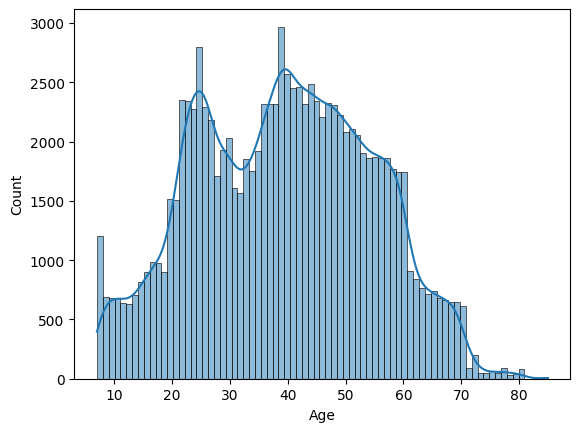

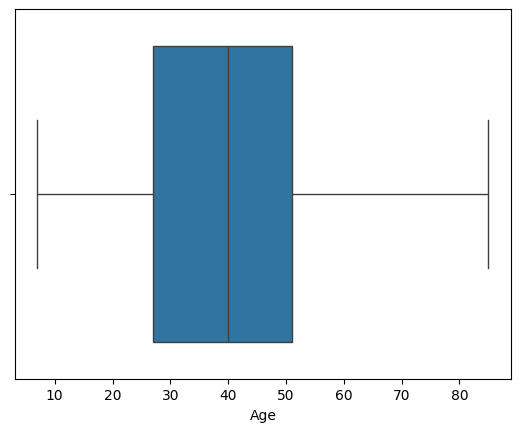

In [3]:
print("Mean:", df['Age'].mean())
print("Median:", df['Age'].median())
print("Variance:", df['Age'].var())

Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

sns.histplot(df['Age'], kde=True)
plt.show()

sns.boxplot(x=df['Age'])
plt.show()

In [4]:
outliers = df[(df['Age'] < Q1 - 1.5*IQR) |
              (df['Age'] > Q3 + 1.5*IQR)]
print(outliers.shape)

(0, 25)


In [ ]:

import numpy as np

p = df['satisfaction'].mean()


synthetic_satisfaction = np.random.binomial(1, p, 1000)

synthetic_age = np.random.normal(df['Age'].mean(), 10, 1000)


print(f"Satisfaction Rate (Mean): {p:.4f}")
print(f"Satisfaction Percentage: {p * 100:.2f}%")
print(f"Average Age of Original Data: {df['Age'].mean():.2f}")

print("\n--- Synthetic Data Summary ---")
print(f"Satisfied count in 1,000 samples: {synthetic_satisfaction.sum()}")
print(f"First 10 synthetic ages: \n{synthetic_age[:10]}")

Satisfaction Rate (Mean): 0.4333
Satisfaction Percentage: 43.33%
Average Age of Original Data: 39.38

--- Synthetic Data Summary ---
Satisfied count in 1,000 samples: 445
First 10 synthetic ages: 
[34.3922628  52.39736101 32.36897512 43.10601778 51.90756479 26.99498819
 35.73122756 34.02977361 29.27633214 38.3420823 ]


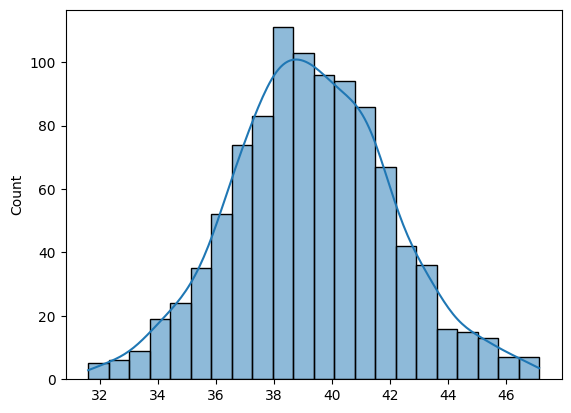

In [6]:
means = []

for i in range(1000):
    sample = df['Age'].sample(30)
    means.append(sample.mean())

sns.histplot(means, kde=True)
plt.show()

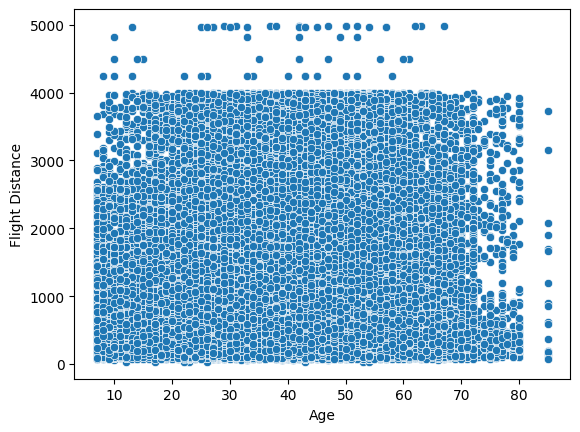

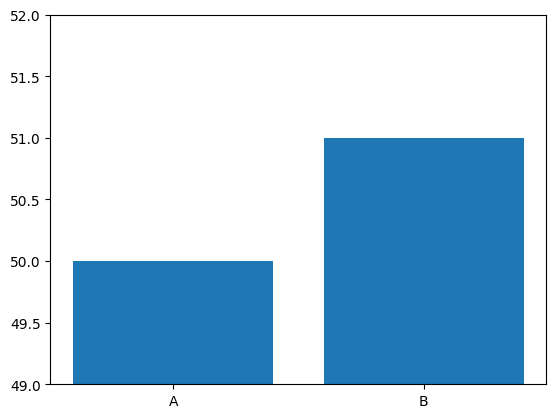

In [7]:
sns.scatterplot(x='Age', y='Flight Distance', data=df)
plt.show()

plt.bar(['A','B'], [50,51])
plt.ylim(49,52)
plt.show()

In [8]:
import scipy.stats as stats

ci = stats.norm.interval(
    0.95,
    loc=df['Age'].mean(),
    scale=stats.sem(df['Age'])
)

print(ci)

(np.float64(39.28780128284208), np.float64(39.471611251805285))


In [9]:
from scipy.stats import ttest_ind

group1 = df[df['satisfaction']==1]['Age']
group0 = df[df['satisfaction']==0]['Age']

t_stat, p_val = ttest_ind(group1, group0)

print("p-value:", p_val)

p-value: 0.0


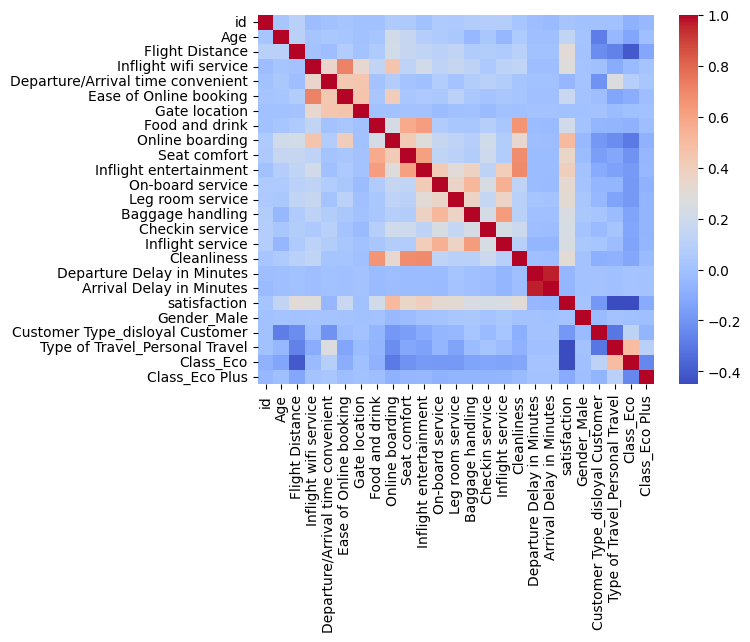

In [10]:
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [11]:
from sklearn.linear_model import LinearRegression

X = df[['Age']]
y = df['Flight Distance']

model = LinearRegression()
model.fit(X, y)

print(model.score(X, y))

0.009892459020834354


In [12]:
X = df[['Age', 'Flight Distance']]
y = df['satisfaction']

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


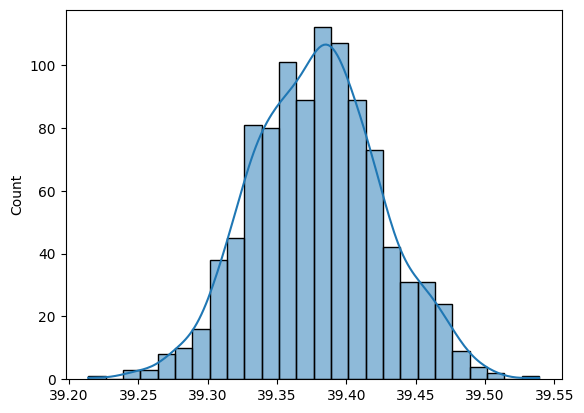

In [13]:
boot = []

for i in range(1000):
    sample = df.sample(frac=1, replace=True)
    boot.append(sample['Age'].mean())

sns.histplot(boot, kde=True)
plt.show()

In [14]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(df[['Age']])

model.fit(X_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
print("Key Insights:")
print("1. Age affects satisfaction slightly")
print("2. Delay and service quality are stronger factors")
print("3. Flight distance has moderate influence")

Key Insights:
1. Age affects satisfaction slightly
2. Delay and service quality are stronger factors
3. Flight distance has moderate influence


In [16]:
print("Conclusion:")
print("Passenger satisfaction depends mainly on service quality and delay, not just age or distance.")

Conclusion:
Passenger satisfaction depends mainly on service quality and delay, not just age or distance.
